In [1]:
%reload_ext autoreload
%autoreload 2

from datetime import datetime
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
from src import Crystals
from utils.loss import MSELoss, KLDivLoss
# from src.models import MDNet

/workspace/pytorch_GNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Crystals("data/processed/v8.pt")
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
dataloader = list(iter(dataloader))

In [3]:
dataloader[0]

DataBatch(x=[932, 8], edge_index=[2, 13398], pos=[932, 3], element=[64], z=[932], dist=[13398], y=[64, 266], mineral=[64], cond_vec=[64, 7], ram_fact=[64], cell_params=[64, 6], folds=[64, 4], ir_y=[64, 266], ir_fact=[64], has_ir=[64], wl=[64], batch=[932], ptr=[65])

In [4]:
len(dataloader)

347

In [6]:
print(dataloader[0].cell_params[0])

tensor([ 5.1890,  8.9960, 20.0960, 90.0000, 95.1800, 90.0000])


In [82]:
import random
i = random.randint(0, len(dataloader)-1)
print(i)
set(dataloader[i].has_ir.tolist())

64


{0.0, 1.0}

306 38


/tmp/ipykernel_10261/3828657251.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


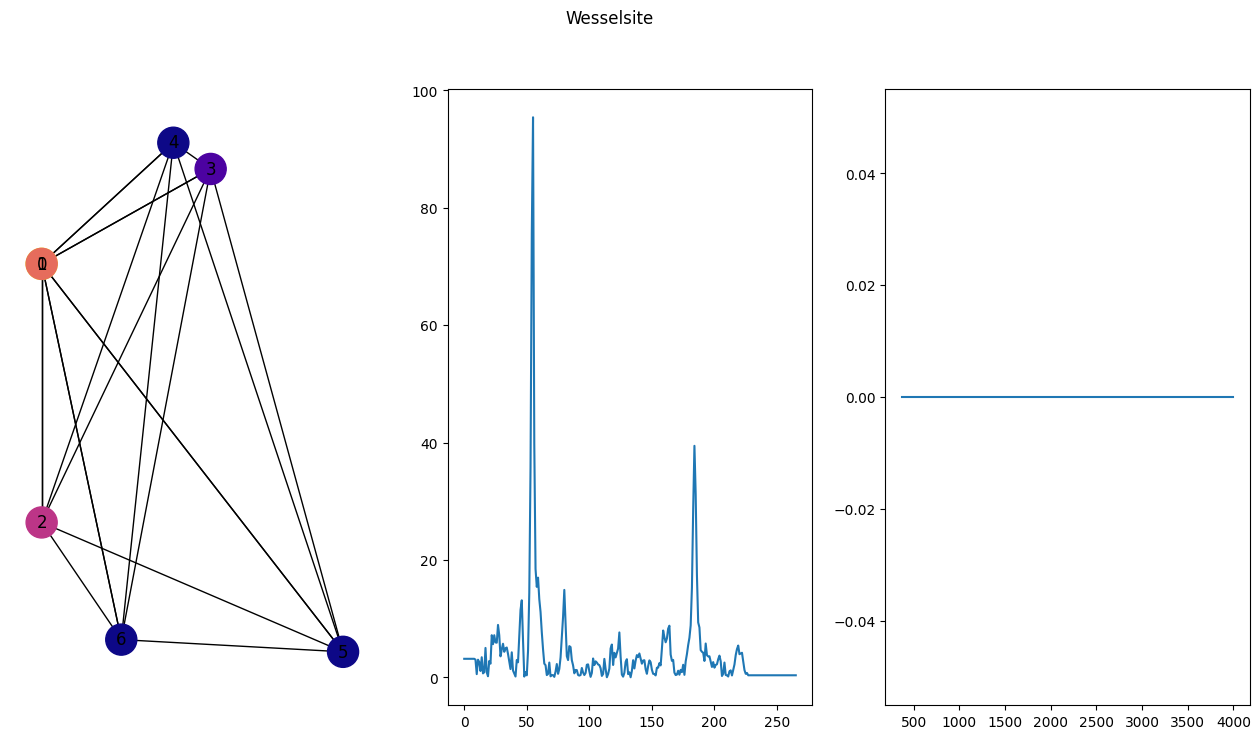

In [93]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from torch_geometric.utils import to_networkx

i = random.randint(0, len(dataloader)-1)
j = random.randint(0, 63)
print(i, j)
G = to_networkx(dataloader[i][j], node_attrs=['z', 'pos'], to_undirected=True)

# Plotting the X-Y plane (Looking down the laser beam)
pos_2d = {a: d['pos'][:2] for a, d in G.nodes(data=True)}

fig, ax = plt.subplots(1,3,figsize=(16, 8))
nx.draw(G, pos_2d, node_color=[d['z'] for i, d in G.nodes(data=True)], 
        with_labels=True, node_size=500, cmap=plt.cm.plasma, ax=ax[0])
ax[1].plot(dataloader[i][j].y[0] * dataloader[i][j].ram_fact[0])
ax[2].plot(np.linspace(370,4000,266), dataloader[i][j].ir_y[0] * dataloader[i][j].ir_fact[0])
fig.suptitle(dataloader[i][j].mineral)
fig.show()

In [27]:
import random


class WaveLenEmb(nn.Module):
    def __init__(self, emb_dim, hidden, n_out, drop=0.3):
        super().__init__()
        self.register_buffer("wl_embs",torch.Tensor([5.14, 5.32, 7.8, 7.85]))
        self.emb = nn.Sequential(
            nn.Embedding(4, emb_dim),
            nn.Linear(emb_dim, hidden*2),
            nn.SiLU(),
            nn.LayerNorm(hidden*2),
            nn.Dropout(drop),
            nn.Linear(hidden*2, n_out)
        )

    def forward(self, x):
        idx = (x == self.wl_embs).long().argmax(dim=-1)
        return self.emb(idx)

ones = torch.zeros(8,1)
for i in range(ones.shape[0]):
    ones[i] = random.choice([5.14, 5.32, 7.8, 7.85])
print(ones)
fold_mod = WaveLenEmb(256,256,64)
fold_mod(ones)
sum([p.numel() for p in fold_mod.parameters()])

tensor([[5.3200],
        [7.8500],
        [7.8500],
        [7.8500],
        [5.1400],
        [5.1400],
        [7.8000],
        [5.1400]])


166464

In [ ]:
from src.embeddings import MDNet1
device = torch.device('cuda')
model = MDNet1().to(device)
# loss_fn = MSELoss()
loss_fn = MSELoss()
loss_name = repr(loss_fn)
now = datetime.now()
dt_string = now.strftime("%Y%m%d-%H%M%S")
dataset_path = '../data/processed/v6.pt'
dataset = Crystals(dataset_path)

train_dataset, val_dataset, test_dataset = dataset.split()
train_loader = DataLoader(train_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

fn = KLDivLoss()
def val(model, val_dataloader):
    model.eval()
    with torch.inference_mode():
        mse = 0
        for data in val_dataloader:
            data = data.to(device)
            pred = model(data)

            mse += fn(pred, data.y)
        return mse / len(val_dataloader)

train_loss = []
val_loss = []
display_epochs = 10
best_val_loss = 0.007
model_save_path = None

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-5)
for batch in train_loader:
    batch = batch.to(device)
    
    if torch.isnan(batch.pos).any() or torch.isnan(batch.wl).any():
        print("batch")
        break
        
    out = model(batch)
    loss = criterion(out, batch.y)
    
    if torch.isnan(loss):
        print("loss")
        break
        
    optimizer.zero_grad()
    loss.backward()
    
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    if torch.isnan(grad_norm):
        print("grad")
        break
    optimizer.step()

In file included from /home/elemantro/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/include/python3.12/Python.h:12,
                 from /tmp/tmpu25x8vyd/__triton_launcher.c:7:
/home/elemantro/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/include/python3.12/pyconfig.h:1877:9: warning: ‘_POSIX_C_SOURCE’ redefined
 1877 | #define _POSIX_C_SOURCE 200809L
      |         ^~~~~~~~~~~~~~~
In file included from /usr/include/bits/libc-header-start.h:33,
                 from /usr/include/stdlib.h:26,
                 from /home/elemantro/PythonProjects/graph12/.venv/lib/python3.12/site-packages/triton/backends/nvidia/include/cuda.h:56,
                 from /tmp/tmpu25x8vyd/__triton_launcher.c:2:
/usr/include/features.h:319:10: note: this is the location of the previous definition
  319 | # define _POSIX_C_SOURCE        202405L
      |          ^~~~~~~~~~~~~~~


In [19]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

In [18]:
a = next(iter(train_loader))
a

DataBatch(x=[665, 8], edge_index=[2, 9584], pos=[665, 3], element=[64], z=[665], dist=[9584], y=[64, 266], mineral=[64], wl=[64], batch=[665], ptr=[65])